In [ ]:
import numpy as np
import tarfile
import os
from pathlib import Path
from PIL import Image, UnidentifiedImageError
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

### Učitavanje podataka

In [54]:
with tarfile.open('data/102flowers.tgz', 'r:gz') as tar:
    tar.extractall(path='data/')

C:\Users\ACV001\AppData\Local\Temp\ipykernel_38144\1829903654.py:2: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path='data/')


In [71]:
IMG_DIR = Path('data/jpg')
labels_raw = scipy.io.loadmat('data/imagelabels.mat')['labels'].flatten()

In [56]:
image_paths = sorted(IMG_DIR.glob('*.jpg'), key=lambda p: int(p.stem.split('_')[1]))

print(f"Total images: {len(image_paths)}")
print(f"Total labels: {len(labels_raw)}")
print(f"Label range: {labels_raw.min()} - {labels_raw.max()}  ({len(np.unique(labels_raw))} unique classes)")

Total images: 8189
Total labels: 8189
Label range: 1 - 102  (102 unique classes)


In [57]:
df = pd.DataFrame({
    'path': image_paths,
    'label': labels_raw
})
df.head()

,path,label
0,data\jpg\image_00001.jpg,77
1,data\jpg\image_00002.jpg,77
2,data\jpg\image_00003.jpg,77
3,data\jpg\image_00004.jpg,77
4,data\jpg\image_00005.jpg,77


### Analiza podataka

In [58]:
class_counts = df['label'].value_counts().sort_index()
median = class_counts.median()
mean = class_counts.mean()

print(f"Min samples per class: {class_counts.min()} (class {class_counts.idxmin()})")
print(f"Max samples per class: {class_counts.max()} (class {class_counts.idxmax()})")
print(f"Mean: {mean:.1f}")
print(f"Std: {class_counts.std():.1f}")
print(f"Median: {median:.0f}")

Min samples per class: 40 (class 1)
Max samples per class: 258 (class 51)
Mean: 80.3
Std: 44.3
Median: 66


In [59]:
below_median = class_counts[class_counts < int(median)]
over_median  = class_counts[class_counts > int(median)]
print(f"Number of classes over median: {len(over_median)}")
print(f"Number of classes below median: {len(below_median)}")

Number of classes over median: 49
Number of classes below median: 50


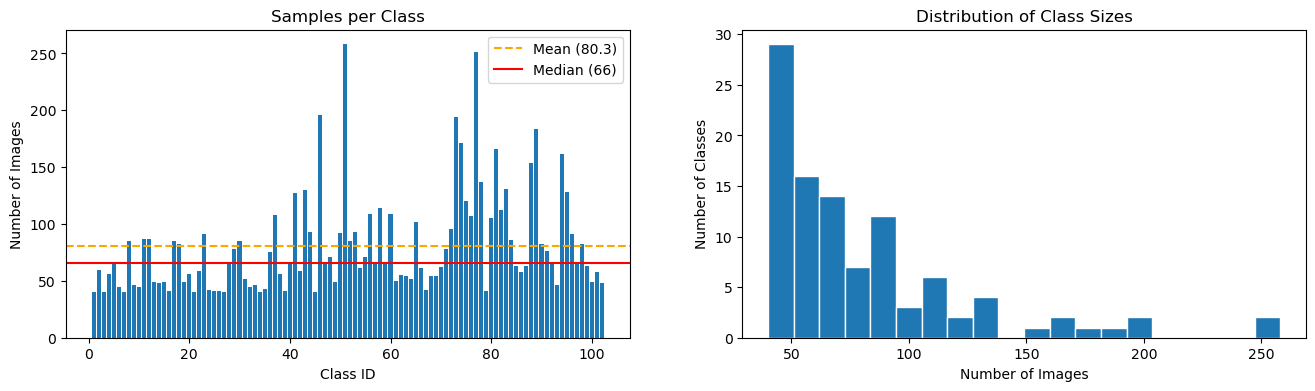

In [60]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (16, 4))

ax1.bar(class_counts.index, class_counts.values)
ax1.axhline(class_counts.mean(), color  = "orange", linestyle="--", label = f'Mean ({class_counts.mean():.1f})')
ax1.axhline(class_counts.median(), color = "red", label = f'Median ({class_counts.median():.0f})')
ax1.set_xlabel('Class ID')
ax1.set_ylabel('Number of Images')
ax1.set_title('Samples per Class')
ax1.legend()

ax2.hist(class_counts.values, bins = 20, edgecolor = 'white')
ax2.set_xlabel('Number of Images')
ax2.set_ylabel('Number of Classes')
ax2.set_title('Distribution of Class Sizes')

plt.show()

In [61]:
img_info = []
for p in image_paths:
    try:
        with Image.open(p) as img:
            w, h = img.size
            mode = img.mode
        file_size = os.path.getsize(p)
        img_info.append({'path': p, 'width': w, 'height': h, 'mode': mode, 'file_size': file_size, 'corrupt': False})
    except (UnidentifiedImageError, OSError):
        img_info.append({'path': p, 'width': None, 'height': None, 'mode': None, 'file_size': None, 'corrupt': True})

img_info = pd.DataFrame(img_info)
df = df.merge(img_info.drop(columns=['path']), left_index=True, right_index=True)
df.head()

,path,label,width,height,mode,file_size,corrupt
0,data\jpg\image_00001.jpg,77,591,500,RGB,49057,False
1,data\jpg\image_00002.jpg,77,625,500,RGB,57207,False
2,data\jpg\image_00003.jpg,77,500,667,RGB,57837,False
3,data\jpg\image_00004.jpg,77,667,500,RGB,56469,False
4,data\jpg\image_00005.jpg,77,508,500,RGB,52293,False


Number of valid images: 8189
Width:  min: 500, max: 1024, mean: 630, std: 96
Height: min: 500, max: 1168, mean: 534, std: 75
Color modes  : {'RGB': 8189}


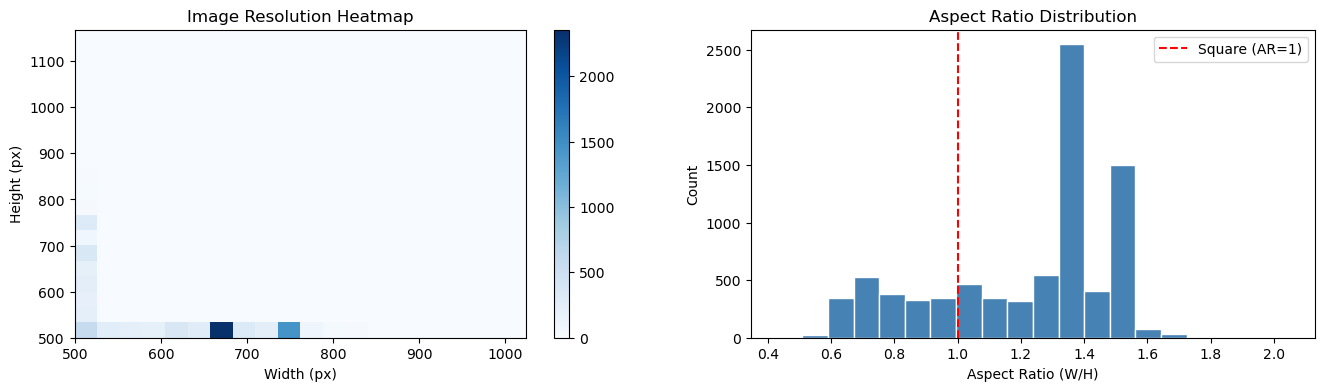

In [89]:
valid = df[~df['corrupt']]
print(f"Number of valid images: {len(valid)}")
print(f"Width:  min: {valid['width'].min()}, max: {valid['width'].max()}, "
      f"mean: {valid['width'].mean():.0f}, std: {valid['width'].std():.0f}")
print(f"Height: min: {valid['height'].min()}, max: {valid['height'].max()}, "
      f"mean: {valid['height'].mean():.0f}, std: {valid['height'].std():.0f}")
print(f"Color modes  : {valid['mode'].value_counts().to_dict()}")

valid = valid.copy()
valid['aspect_ratio'] = valid['width'] / valid['height']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

ax1.hist2d(valid['width'], valid['height'], bins=20, cmap='Blues')
ax1.set_xlabel('Width (px)'); ax1.set_ylabel('Height (px)')
ax1.set_title('Image Resolution Heatmap')
plt.colorbar(ax1.collections[0], ax=ax1)

ax2.hist(valid['aspect_ratio'], bins=20, color='steelblue', edgecolor='white')
ax2.axvline(1.0, color='red', linestyle='--', label='Square (AR=1)')
ax2.set_xlabel('Aspect Ratio (W/H)'); ax2.set_ylabel('Count')
ax2.set_title('Aspect Ratio Distribution')
ax2.legend()

plt.show()


In [68]:
corrupt_df = df[df['corrupt'] == True]
print(f"Corrupt images : {len(corrupt_df)}")

tiny_threshold_kb = 2.0
tiny = df[(~df['corrupt']) & (df['file_size'] < tiny_threshold_kb * 1024)]
print(f"Very small files (< {tiny_threshold_kb} kB): {len(tiny)}")

non_rgb = df[(~df['corrupt']) & (df['mode'] != 'RGB')]
print(f"Non-RGB images: {len(non_rgb)}")


Corrupt images : 0
Very small files (< 2.0 kB): 0
Non-RGB images: 0


Svi podaci su validni.

In [72]:
class_ids = np.random.choice(np.unique(df['label'].values), size=20, replace=False)
class_ids.sort()

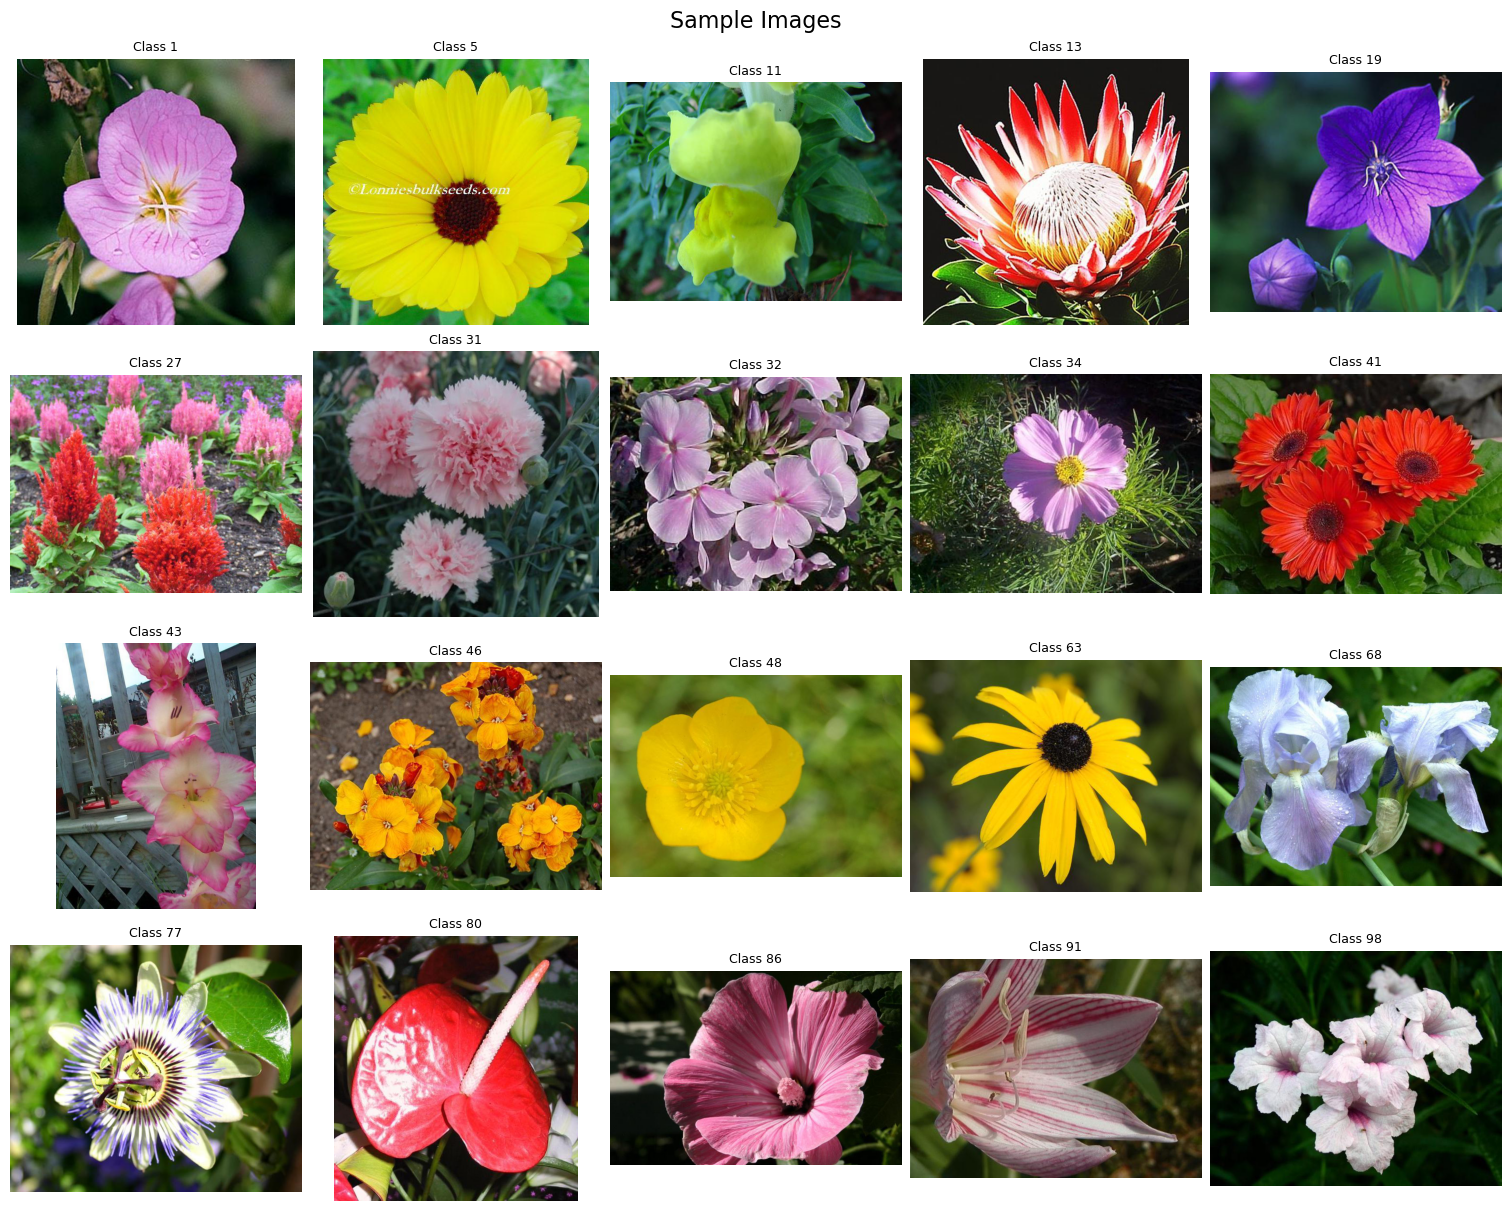

In [84]:
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()

for ax, id in zip(axes, class_ids):
    sample_path = df[df['label'] == id]['path'].iloc[0]
    img = Image.open(sample_path).convert('RGB')
    ax.imshow(img)
    ax.set_title(f'Class {id}', fontsize=9)
    ax.axis('off')

fig.suptitle('Sample Images', fontsize=16)
fig.set_layout_engine('constrained')
plt.show()